# Detecting AI vs Real Images using Machine Learning

## Overview
This notebook implements a machine learning pipeline for classifying images as either real or AI-generated. The workflow includes data preprocessing, dimensionality reduction, training of classical machine learning models (Logistic Regression and SVM), and training of convolutional neural networks (CNNs). The goal is to compare the performance of these different approaches and analyze their behavior on image data.

## Methods Implemented
- Image preprocessing (resizing, normalization)
- Principal Component Analysis (PCA)
- Logistic Regression
- Support Vector Machine (SVM)
- Convolutional Neural Networks (baseline and improved)

## Notes on Implementation
- Classical models operate on flattened image representations with PCA applied to reduce dimensionality.
- CNN models operate directly on image tensors and preserve spatial structure.

## Use of AI Assistance
This notebook was developed with the assistance of a large language model (LLM) for guidance on code structure, debugging, and implementation details. All design choices, analysis, and final results were reviewed and understood by the author.





## Required Libraries

The following libraries are used throughout this notebook for data processing, visualization, and model training, including `NumPy`, `scikit-learn`, `PyTorch`, and `Matplotlib`.

## Installing and Downloading Dataset from Kaggle

This section installs and configures the Kaggle API in order to download the dataset used in this project directly within the notebook.

- The Kaggle API is first installed to enable programmatic dataset access.
- The `kaggle.json` file contains the required API credentials and is placed in the appropriate directory with secure permissions.
- The dataset is then downloaded using the Kaggle API and extracted for use.

This ensures that the notebook is fully reproducible and can retrieve the dataset without requiring a manual download.

The dataset used is the AI vs Real Images dataset available on Kaggle.

In [ ]:
!pip install kaggle

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d rhythmghai/ai-vs-real-images-dataset
!unzip ai-vs-real-images-dataset.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/rhythmghai/ai-vs-real-images-dataset
License(s): CC-BY-NC-SA-4.0
100% 237M/237M [00:03<00:00, 81.5MB/s]

Archive:  ai-vs-real-images-dataset.zip
  inflating: Ai_generated_dataset/animals/image-10.png  
  inflating: Ai_generated_dataset/animals/image-11.png  
  inflating: Ai_generated_dataset/animals/image-12.png  
  inflating: Ai_generated_dataset/animals/image-13.png  
  inflating: Ai_generated_dataset/animals/image-14.png  
  inflating: Ai_generated_dataset/animals/image-15.png  
  inflating: Ai_generated_dataset/animals/image-16.png  
  inflating: Ai_generated_dataset/animals/image-17.png  
  inflating: Ai_generated_dataset/animals/image-18.png  
  inflating: Ai_generated_dataset/animals/image-19.png  
  inflating: Ai_generated_dataset/animals/image-2.png  
  inflating: Ai_generated_dataset/animals/image-20.

## Loading and Preprocessing Images

This block defines a function to load images from the dataset directory. It iterates through both the real and AI-generated folders, processes each image, and assigns labels accordingly.

Each image is:
- converted to RGB format
- resized to 64×64 for computational efficiency
- normalized to the range [0,1]

The output consists of:
- X: array of image data
- y: corresponding labels (0 = real, 1 = AI-generated)

In [ ]:
import os
from PIL import Image
import numpy as np

IMG_SIZE = 64

def load_images(base_dir):
    images = []
    labels = []

    datasets = {
        "real_dataset": 0,
        "Ai_generated_dataset": 1
    }

    for dataset_name, label in datasets.items():
        dataset_path = os.path.join(base_dir, dataset_name)

        for category in os.listdir(dataset_path):
            category_path = os.path.join(dataset_path, category)

            if not os.path.isdir(category_path):
                continue

            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)

                try:
                    img = Image.open(img_path).convert("RGB")
                    img = img.resize((IMG_SIZE, IMG_SIZE))
                    img = np.array(img) / 255.0

                    images.append(img)
                    labels.append(label)
                except:
                    continue

    return np.array(images), np.array(labels)

## Loading Dataset

This block calls the image loading function and constructs the dataset arrays. A sanity check is performed to verify the shape of the data and the class distribution.

In [ ]:
X, y = load_images("/content")

In [ ]:
print(X.shape)
print(y.shape)
print(np.unique(y, return_counts=True))

(995, 64, 64, 3)
(995,)
(array([0, 1]), array([745, 250]))


## Train-Test Split

The dataset is split into training and testing sets using an 80/20 split. This allows for model evaluation on unseen data and helps prevent overfitting.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Dimensionality Reduction with PCA

For classical machine learning models, images must be converted into one-dimensional feature vectors. This block:
- flattens each image into a vector
- applies PCA to reduce dimensionality to 100 components

This reduces computational cost while preserving the most important variance in the data.

In [ ]:
from sklearn.decomposition import PCA

# Flatten images
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

# PCA
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print("PCA shape:", X_train_pca.shape)

PCA shape: (796, 100)


## Logistic Regression Model

This block trains a logistic regression classifier using the PCA-transformed data. The model learns a linear decision boundary to separate real and AI-generated images.

After training, predictions are generated and accuracy is computed on the test set.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_pca, y_train)

log_pred = log_model.predict(X_test_pca)
log_acc = log_model.score(X_test_pca, y_test)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.7487437185929648


## Support Vector Machine (SVM)

This block trains a linear SVM classifier on the PCA-transformed data. The SVM attempts to find a hyperplane that maximizes the margin between classes.

Performance is evaluated using accuracy on the test set.

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_pca, y_train)

svm_pred = svm_model.predict(X_test_pca)
svm_acc = svm_model.score(X_test_pca, y_test)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.7889447236180904


## Model Evaluation (Classical Models)

This block computes performance metrics such as:
- classification report (precision, recall, F1-score)
- confusion matrix

These metrics provide insight into how well the model performs on each class, especially in the presence of class imbalance.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("Logistic Regression Report:")
print(classification_report(y_test, log_pred))

print("SVM Report:")
print(classification_report(y_test, svm_pred))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       153
           1       0.43      0.28      0.34        46

    accuracy                           0.75       199
   macro avg       0.62      0.59      0.59       199
weighted avg       0.72      0.75      0.73       199

SVM Report:
              precision    recall  f1-score   support

           0       0.81      0.95      0.87       153
           1       0.61      0.24      0.34        46

    accuracy                           0.79       199
   macro avg       0.71      0.60      0.61       199
weighted avg       0.76      0.79      0.75       199



## Preparing Data for CNN Models

This block converts the dataset into PyTorch tensors and prepares DataLoader objects. The image dimensions are rearranged to match PyTorch’s expected input format (channels first).

Batching is also applied to improve training efficiency.

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0,3,1,2)
X_test_t = torch.tensor(X_test, dtype=torch.float32).permute(0,3,1,2)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32)

## Baseline CNN Architecture

This block defines a simple convolutional neural network consisting of:
- two convolutional layers
- max pooling layers
- a fully connected layer
- output layer for classification

This model captures basic spatial features such as edges and textures.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 16 * 16, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64 → 32
        x = self.pool(F.relu(self.conv2(x)))  # 32 → 16
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()

## Training Baseline CNN

This block trains the baseline CNN using:
- cross-entropy loss
- Adam optimizer

Training is performed over several epochs, and loss is monitored to track learning progress.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 13.8597
Epoch 2, Loss: 11.2320
Epoch 3, Loss: 9.9863
Epoch 4, Loss: 9.5514
Epoch 5, Loss: 8.3698


## Evaluating Baseline CNN

After training, the model is evaluated on the test set. Predictions are generated and accuracy is computed.

This provides a comparison against classical models.

In [ ]:
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

cnn_acc = correct / total
print("CNN Accuracy:", cnn_acc)

CNN Accuracy: 0.9095477386934674


## Confusion Matrix (Baseline CNN)

This block visualizes the confusion matrix for the baseline CNN model. The confusion matrix provides a breakdown of correct and incorrect predictions across both classes (real and AI-generated images).

This allows us to analyze how well the baseline CNN distinguishes between the two classes and to identify any bias toward the majority class.

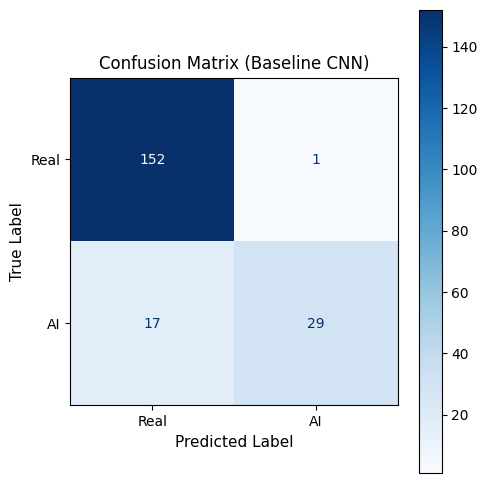

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Real", "AI"])

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title("Confusion Matrix (Baseline CNN)", fontsize=12)
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.show()

## Improved CNN Architecture

This block defines an enhanced CNN with:
- an additional convolutional layer
- increased feature depth
- dropout for regularization

The goal is to improve model capacity and reduce overfitting.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class BetterCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64 → 32
        x = self.pool(F.relu(self.conv2(x)))  # 32 → 16
        x = self.pool(F.relu(self.conv3(x)))  # 16 → 8

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

better_model = BetterCNN()

In [ ]:
import torch

optimizer = torch.optim.Adam(better_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

## Training Improved CNN

This block trains the improved CNN using the same optimization setup as the baseline model. Additional training epochs and increased model complexity allow the network to learn more advanced features.

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    better_model.train()
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = better_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Evaluate during training
    better_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = better_model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Test Acc: {correct/total:.4f}")

Epoch 1, Loss: 15.2491, Test Acc: 0.7688
Epoch 2, Loss: 15.0437, Test Acc: 0.7688
Epoch 3, Loss: 12.5601, Test Acc: 0.8543
Epoch 4, Loss: 10.8863, Test Acc: 0.8643
Epoch 5, Loss: 10.3389, Test Acc: 0.8844
Epoch 6, Loss: 9.6233, Test Acc: 0.8894
Epoch 7, Loss: 8.7130, Test Acc: 0.8945
Epoch 8, Loss: 8.3585, Test Acc: 0.8844
Epoch 9, Loss: 8.1835, Test Acc: 0.8894
Epoch 10, Loss: 7.7265, Test Acc: 0.8844


## Evaluating Improved CNN

The improved model is evaluated on the test set. Predictions and accuracy are computed, allowing for direct comparison with the baseline CNN and classical models.

In [ ]:
better_model.eval()
correct = 0
total = 0

better_preds = []
better_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = better_model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        better_preds.extend(predicted.numpy())
        better_labels.extend(labels.numpy())

better_cnn_acc = correct / total
print("Improved CNN Accuracy:", better_cnn_acc)

Improved CNN Accuracy: 0.8844221105527639


## Confusion Matrix (Improved CNN)

This block visualizes the confusion matrix for the improved CNN model. By comparing this matrix to the baseline CNN, we can observe how architectural improvements impact classification performance.

In particular, this helps evaluate whether the improved model reduces misclassification, especially for the minority class.

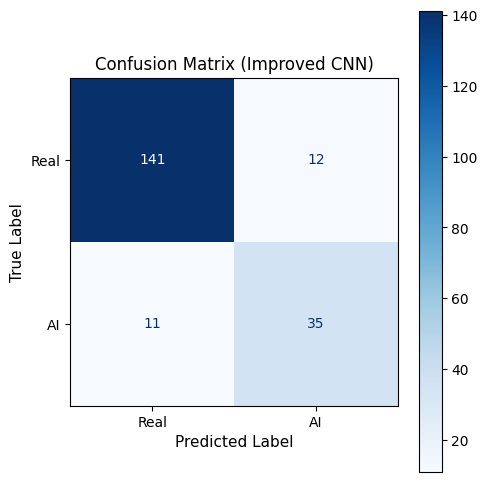

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(better_labels, better_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "AI"]
)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title("Confusion Matrix (Improved CNN)", fontsize=12)
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.show()

## Model Accuracy Visualization

This block creates a bar chart comparing the performance of all models tested in this project. The accuracies for Logistic Regression, SVM, the baseline CNN, and the improved CNN are plotted side-by-side.

Each bar represents the classification accuracy achieved on the test set, allowing for a clear visual comparison of model performance. Labels are added above each bar to display the exact accuracy values.

This visualization highlights the performance gap between classical machine learning models and CNN-based approaches, reinforcing the importance of spatial feature learning for image classification.

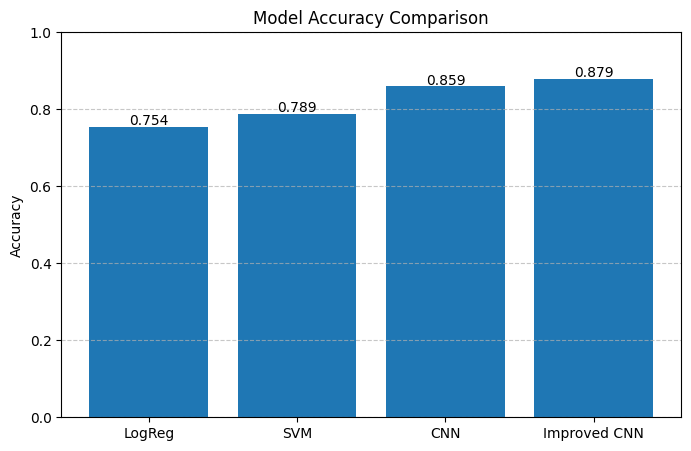

In [ ]:
import matplotlib.pyplot as plt

# Accuracies
models = ['LogReg', 'SVM', 'CNN', 'Improved CNN']
accuracies = [0.7538, 0.7889, 0.8593, 0.8794]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005,
             f"{yval:.3f}", ha='center', fontsize=10)

plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Visualizing Model Predictions

This block randomly selects images from the test set and displays:
- the true label
- predictions from each model

This helps provide qualitative insight into model behavior and identify cases where models succeed or fail.

In [ ]:
import random
import matplotlib.pyplot as plt
import torch

def label_to_name(label):
    return "Real" if label == 0 else "AI"

def show_random_prediction():
    idx = random.randint(0, len(X_test) - 1)

    img = X_test[idx]
    true_label = y_test[idx]

    # ---- Logistic + SVM (PCA) ----
    img_flat = img.reshape(1, -1)
    img_pca = pca.transform(img_flat)

    log_pred = log_model.predict(img_pca)[0]
    svm_pred = svm_model.predict(img_pca)[0]

    # ---- CNN ----
    img_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1).unsqueeze(0)

    model.eval()
    better_model.eval()

    with torch.no_grad():
        cnn_out = model(img_tensor)
        better_out = better_model(img_tensor)

        cnn_pred = torch.argmax(cnn_out, dim=1).item()
        better_pred = torch.argmax(better_out, dim=1).item()

    # ---- Plot ----
    plt.imshow(img)
    plt.axis('off')

    plt.title(
        f"True: {label_to_name(true_label)}\n"
        f"LogReg: {label_to_name(log_pred)} | "
        f"SVM: {label_to_name(svm_pred)}\n"
        f"CNN: {label_to_name(cnn_pred)} | "
        f"Improved CNN: {label_to_name(better_pred)}"
    )

    plt.show()

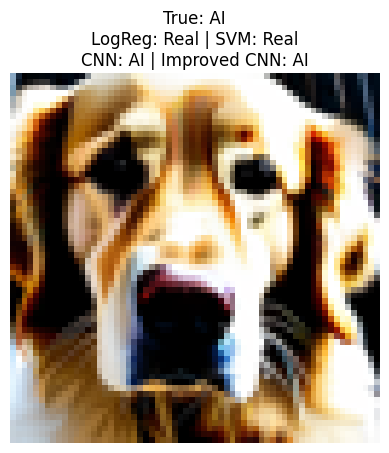

In [ ]:
show_random_prediction()